# Class Task 1 — Heart Failure Clinical Records Analysis

**Cairo University — Faculty of Engineering**
**Course:** Biomedical Data Analytics
**Student Name:** Mahmoud Mohamed Abdelfattah
**Student ID:** 4220142

---

## Overview
Using the Heart Failure Clinical Records dataset, we will explore, visualize, clean, filter, and normalize the data. This notebook tells a clear data analytics story with brief explanations before each step.

**Dataset:** Heart Failure Clinical Records (299 patients, 13 features)
- **Demographic:** age, sex
- **Clinical:** anaemia, diabetes, high_blood_pressure, smoking
- **Lab tests:** creatinine_phosphokinase, ejection_fraction, platelets, serum_creatinine, serum_sodium
- **Follow-up:** time
- **Target:** DEATH_EVENT

In [10]:
# ─── Student Information ───
print("=" * 55)
print("  Cairo University — Faculty of Engineering")
print("  Course : Biomedical Data Analytics")
print("  Task   : Class Task 1")
print("  Student: Mahmoud Mohamed Abdelfattah")
print("  ID     : 4220142")
print("=" * 55)

  Cairo University — Faculty of Engineering
  Course : Biomedical Data Analytics
  Task   : Class Task 1
  Student: Mahmoud Mohamed Abdelfattah
  ID     : 4220142


In [11]:
# ─── Install & Import Required Libraries ───
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set plot style for clean visuals
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully!")

All libraries imported successfully!


## Load Dataset

We load the Heart Failure Clinical Records dataset. This dataset contains medical records of 299 patients who had heart failure, collected during their follow-up period. Each patient profile has 13 clinical features.

In [12]:
# ─── Load the Dataset ───
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

# Display first 5 rows
print("─── First 5 Rows ───")
df.head()

Dataset loaded successfully!
Shape: 299 rows × 13 columns

─── First 5 Rows ───


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [13]:
# Display last 5 rows
print("─── Last 5 Rows ───")
df.tail()

─── Last 5 Rows ───


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
294,62.0,0,61,1,38,1,155000.0,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.0,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.0,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.0,1.4,140,1,1,280,0
298,50.0,0,196,0,45,0,395000.0,1.6,136,1,1,285,0


In [14]:
# General overview of the dataset
print("─── Dataset Info ───")
df.info()
print(f"\n─── Column Names ───\n{list(df.columns)}")

─── Dataset Info ───
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 

---
# Part 1 — Data Exploration

## 1.1 Data Types Inspection

We examine the data type of each column to understand the nature of our variables:
- **Binary/Categorical columns** (stored as int64, values 0 or 1): `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, `smoking`, `DEATH_EVENT`
- **Continuous numeric columns** (float64 or int64): `age`, `creatinine_phosphokinase`, `ejection_fraction`, `platelets`, `serum_creatinine`, `serum_sodium`, `time`

Understanding data types is crucial for selecting appropriate analysis methods and visualizations.

In [15]:
# ─── 1.1 Data Types of Each Column ───
print("─── Data Types ───")
print(df.dtypes)

# Separate binary vs continuous columns for reference
binary_cols = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking', 'DEATH_EVENT']
continuous_cols = ['age', 'creatinine_phosphokinase', 'ejection_fraction',
                   'platelets', 'serum_creatinine', 'serum_sodium', 'time']

print(f"\nBinary/Categorical columns ({len(binary_cols)}): {binary_cols}")
print(f"Continuous/Numeric columns  ({len(continuous_cols)}): {continuous_cols}")

─── Data Types ───
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Binary/Categorical columns (6): ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking', 'DEATH_EVENT']
Continuous/Numeric columns  (7): ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'time']


## 1.2 Missing and Suspicious Values

We check for:
1. **Missing values (NaN):** Any gaps in the data that need imputation.
2. **Suspicious values:** Physiologically impossible or placeholder values, such as repeated platelet counts (263358.03 appears multiple times — likely a default/placeholder value).
3. **Duplicate rows:** Exact copies that might inflate our analysis.

In [16]:
# ─── 1.2 Check for Missing Values ───
print("─── Missing Values Per Column ───")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

# ─── Check for Duplicated Rows ───
dup_count = df.duplicated().sum()
print(f"\nDuplicated rows: {dup_count}")

# ─── Suspicious Values Investigation ───
print("\n─── Suspicious Values ───")

# Check the repeated platelets value 263358.03
placeholder_count = (df['platelets'] == 263358.03).sum()
print(f"Platelets = 263358.03 (suspected placeholder): {placeholder_count} occurrences")

# Check for impossible ages (too young or too old for heart failure study)
print(f"Age range: {df['age'].min()} – {df['age'].max()}")

# Check ejection_fraction extremes
print(f"Ejection fraction range: {df['ejection_fraction'].min()} – {df['ejection_fraction'].max()}")
print(f"  → EF < 15 (extremely low): {(df['ejection_fraction'] < 15).sum()} patients")
print(f"  → EF > 70 (unusually high): {(df['ejection_fraction'] > 70).sum()} patients")

# Check serum_creatinine for extreme values
print(f"Serum creatinine range: {df['serum_creatinine'].min()} – {df['serum_creatinine'].max()}")
print(f"  → Values > 5 (very high): {(df['serum_creatinine'] > 5).sum()} patients")

# Check serum_sodium for extreme values
print(f"Serum sodium range: {df['serum_sodium'].min()} – {df['serum_sodium'].max()}")
print(f"  → Values < 120 (dangerously low): {(df['serum_sodium'] < 120).sum()} patients")

─── Missing Values Per Column ───
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Total missing values: 0

Duplicated rows: 0

─── Suspicious Values ───
Platelets = 263358.03 (suspected placeholder): 25 occurrences
Age range: 40.0 – 95.0
Ejection fraction range: 14 – 80
  → EF < 15 (extremely low): 1 patients
  → EF > 70 (unusually high): 1 patients
Serum creatinine range: 0.5 – 9.4
  → Values > 5 (very high): 5 patients
Serum sodium range: 113 – 148
  → Values < 120 (dangerously low): 2 patients


## 1.3 Descriptive Statistics & Conclusions

We compute summary statistics for all columns. Key observations will be noted below the output.

In [17]:
# ─── 1.3 Descriptive Statistics ───
print("─── Full Descriptive Statistics ───")
df.describe().T  # Transpose for easier reading

─── Full Descriptive Statistics ───


,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


In [18]:
# ─── Distribution of Binary Columns ───
print("─── Binary Column Distributions ───\n")
for col in binary_cols:
    counts = df[col].value_counts()
    print(f"{col}:")
    print(f"  0 → {counts.get(0, 0)}  |  1 → {counts.get(1, 0)}")
    print()

─── Binary Column Distributions ───

anaemia:
  0 → 170  |  1 → 129

diabetes:
  0 → 174  |  1 → 125

high_blood_pressure:
  0 → 194  |  1 → 105

sex:
  0 → 105  |  1 → 194

smoking:
  0 → 203  |  1 → 96

DEATH_EVENT:
  0 → 203  |  1 → 96



### Part 1 — Conclusions

**Data Types:**
- No columns have incorrect data types. Binary features are stored as integers (0/1), and continuous features are stored as float64 or int64.
- The `age` column contains decimal values (e.g., 60.667) suggesting precise measurements.

**Missing Values:**
- There are **no missing (NaN) values** in the dataset.

**Suspicious Values:**
- **Platelets = 263358.03** appears multiple times and is suspected to be a **placeholder/default value** that should be treated in the cleaning phase.
- **Serum creatinine** has extreme values (up to 9.4 mg/dL), which are rare but clinically possible in severe renal failure.
- **Ejection fraction** ranges from 14% to 80% — values below 20% indicate severe heart failure.

**Statistical Observations:**
- The mean age is ~61 years, typical for heart failure patients.
- **Creatinine phosphokinase** is highly right-skewed (mean ≈ 582 vs median ≈ 250), indicating outliers.
- **DEATH_EVENT** shows class imbalance: approximately 2/3 survived vs 1/3 died, which is important for any predictive modeling.
- **Serum sodium** has a narrow range (113–148), with most values between 134–140 mEq/L (normal).

---
# Part 2 — Visualization & Filtering

## 2.1 Line Plots of Selected Features

We choose **serum_creatinine** and **ejection_fraction** for line plots because they are two of the most clinically important biomarkers for heart failure prognosis:
- **Serum creatinine** reflects kidney function, which deteriorates with heart failure.
- **Ejection fraction** measures how much blood the heart pumps per beat — the primary indicator of heart failure severity.

We sort the data by the `time` (follow-up period) column to create a meaningful temporal sequence.

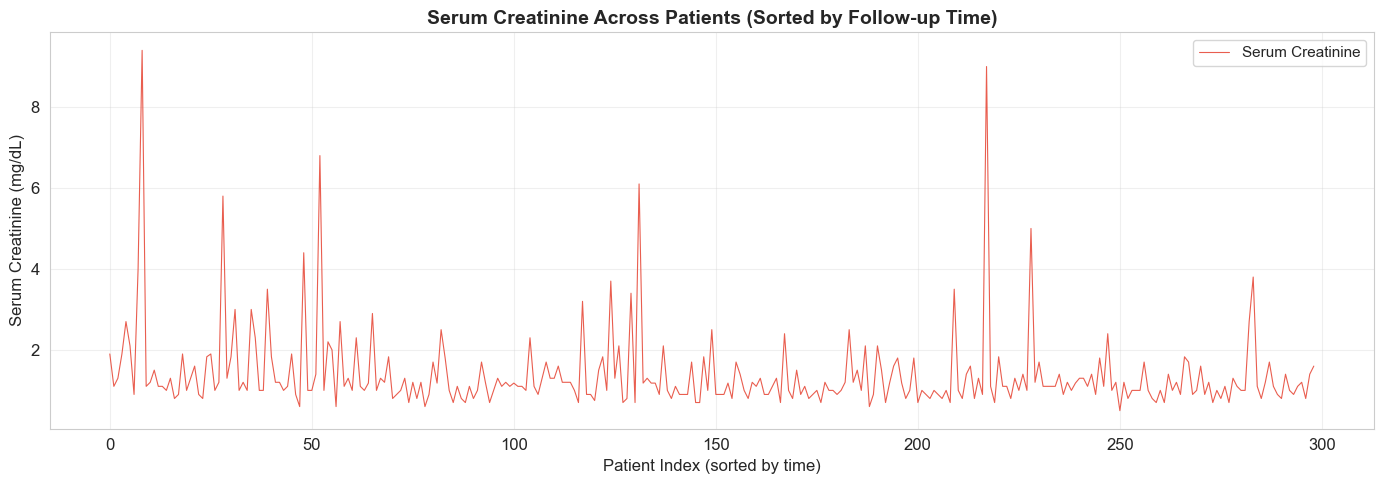

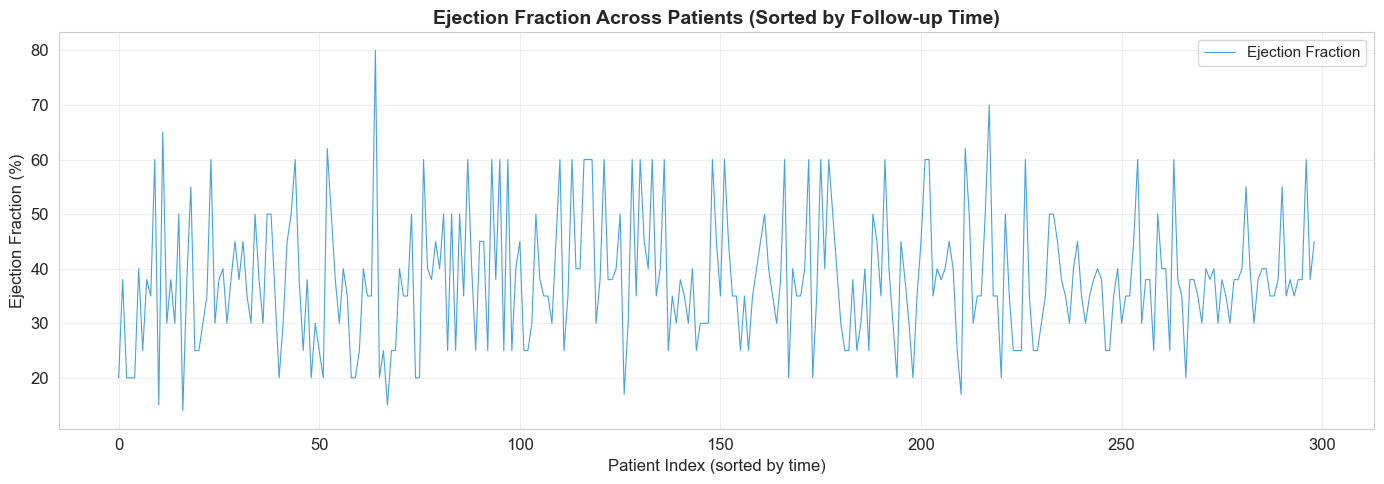

In [19]:
# ─── 2.1 Line Plots ───
# Sort data by follow-up time for meaningful temporal visualization
df_sorted = df.sort_values('time').reset_index(drop=True)

# ── Line Plot 1: Serum Creatinine ──
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_sorted.index, df_sorted['serum_creatinine'], color='#e74c3c',
        linewidth=0.8, alpha=0.9, label='Serum Creatinine')
ax.set_title('Serum Creatinine Across Patients (Sorted by Follow-up Time)', fontsize=14, fontweight='bold')
ax.set_xlabel('Patient Index (sorted by time)', fontsize=12)
ax.set_ylabel('Serum Creatinine (mg/dL)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Line Plot 2: Ejection Fraction ──
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_sorted.index, df_sorted['ejection_fraction'], color='#3498db',
        linewidth=0.8, alpha=0.9, label='Ejection Fraction')
ax.set_title('Ejection Fraction Across Patients (Sorted by Follow-up Time)', fontsize=14, fontweight='bold')
ax.set_xlabel('Patient Index (sorted by time)', fontsize=12)
ax.set_ylabel('Ejection Fraction (%)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2.2 Simulate a Noisy Signal

We select **serum_creatinine** (sorted by time) as the base signal and add **Gaussian noise** to simulate measurement/sensor noise that is commonly encountered in biomedical data acquisition systems (e.g., lab instrument variability, electronic interference).

Gaussian noise is chosen because it models the most common type of random noise in biomedical measurements, following a normal distribution centered around zero.

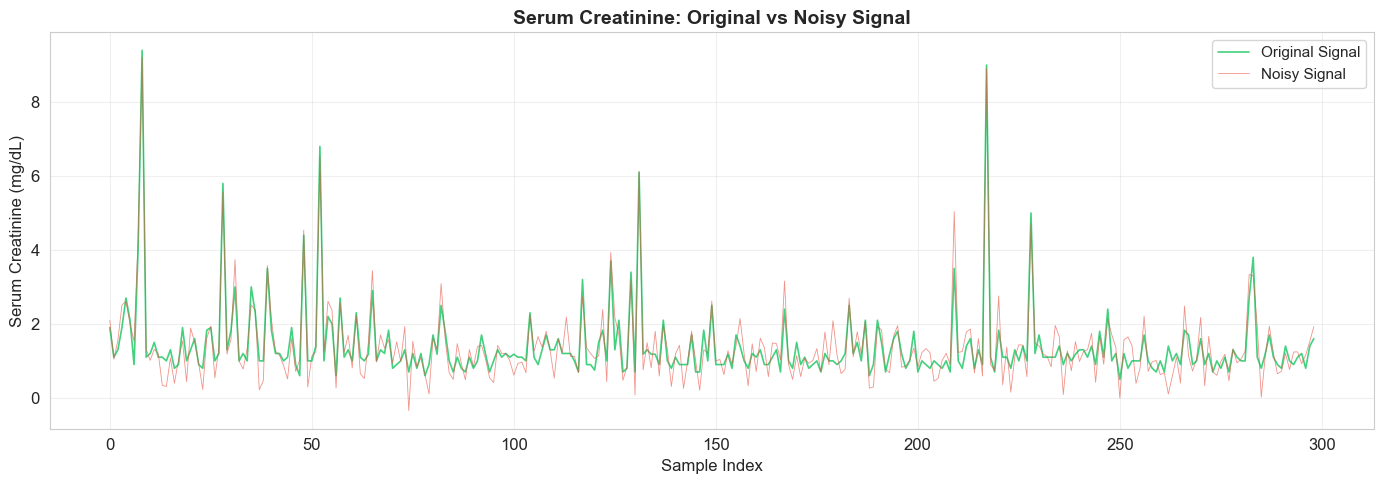

Noise statistics — Mean: -0.0031, Std: 0.3934


In [20]:
# ─── 2.2 Simulate Noisy Signal ───
np.random.seed(42)  # For reproducibility

# Original signal: serum_creatinine sorted by time
original_signal = df_sorted['serum_creatinine'].values.copy()

# Add Gaussian noise (mean=0, std=0.4)
noise = np.random.normal(loc=0, scale=0.4, size=len(original_signal))
noisy_signal = original_signal + noise

# Plot original vs noisy signal
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(original_signal, color='#2ecc71', linewidth=1.2, label='Original Signal', alpha=0.9)
ax.plot(noisy_signal, color='#e74c3c', linewidth=0.6, alpha=0.6, label='Noisy Signal')
ax.set_title('Serum Creatinine: Original vs Noisy Signal', fontsize=14, fontweight='bold')
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('Serum Creatinine (mg/dL)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Noise statistics — Mean: {noise.mean():.4f}, Std: {noise.std():.4f}")

## 2.3 Apply Filter to Clean the Noisy Signal

### Filter Choice: **Butterworth Low-Pass Filter**

**Justification:**
- The **Butterworth filter** is chosen because it has a **maximally flat frequency response** in the passband, meaning it preserves the true signal shape with minimal distortion while effectively attenuating high-frequency noise.
- Unlike Chebyshev filters (which have ripples), the Butterworth filter provides a smooth transition and is ideal for biomedical signals where preserving the original waveform shape is critical.
- We use `scipy.signal.butter()` to design the filter and `filtfilt()` for zero-phase filtering (no time delay introduced).

**Parameters:**
- **Order = 3:** A moderate order provides a good balance between noise removal and signal preservation.
- **Cutoff frequency = 0.05** (normalized): Tuned to remove high-frequency noise while keeping the underlying trend.

We also compare with a **Simple Moving Average** filter for reference.

In [21]:
# ─── 2.3 Apply Butterworth Low-Pass Filter ───

# Design Butterworth low-pass filter
order = 3           # Filter order
cutoff = 0.05       # Normalized cutoff frequency (0 to 1, where 1 = Nyquist)
b, a = butter(order, cutoff, btype='low')

# Apply zero-phase filtering (no time delay)
filtered_signal_butter = filtfilt(b, a, noisy_signal)

# ── Also apply Simple Moving Average for comparison ──
window_size = 10
moving_avg_signal = pd.Series(noisy_signal).rolling(window=window_size, center=True).mean().values

print(f"Butterworth filter — Order: {order}, Cutoff: {cutoff}")
print(f"Moving Average — Window size: {window_size}")
print("Filters applied successfully!")

Butterworth filter — Order: 3, Cutoff: 0.05
Moving Average — Window size: 10
Filters applied successfully!


## 2.4 Plot Original, Noisy, and Filtered Signals Together

Below we compare all three signals on one plot. The Butterworth filter should closely follow the original signal's shape while removing the high-frequency noise components.

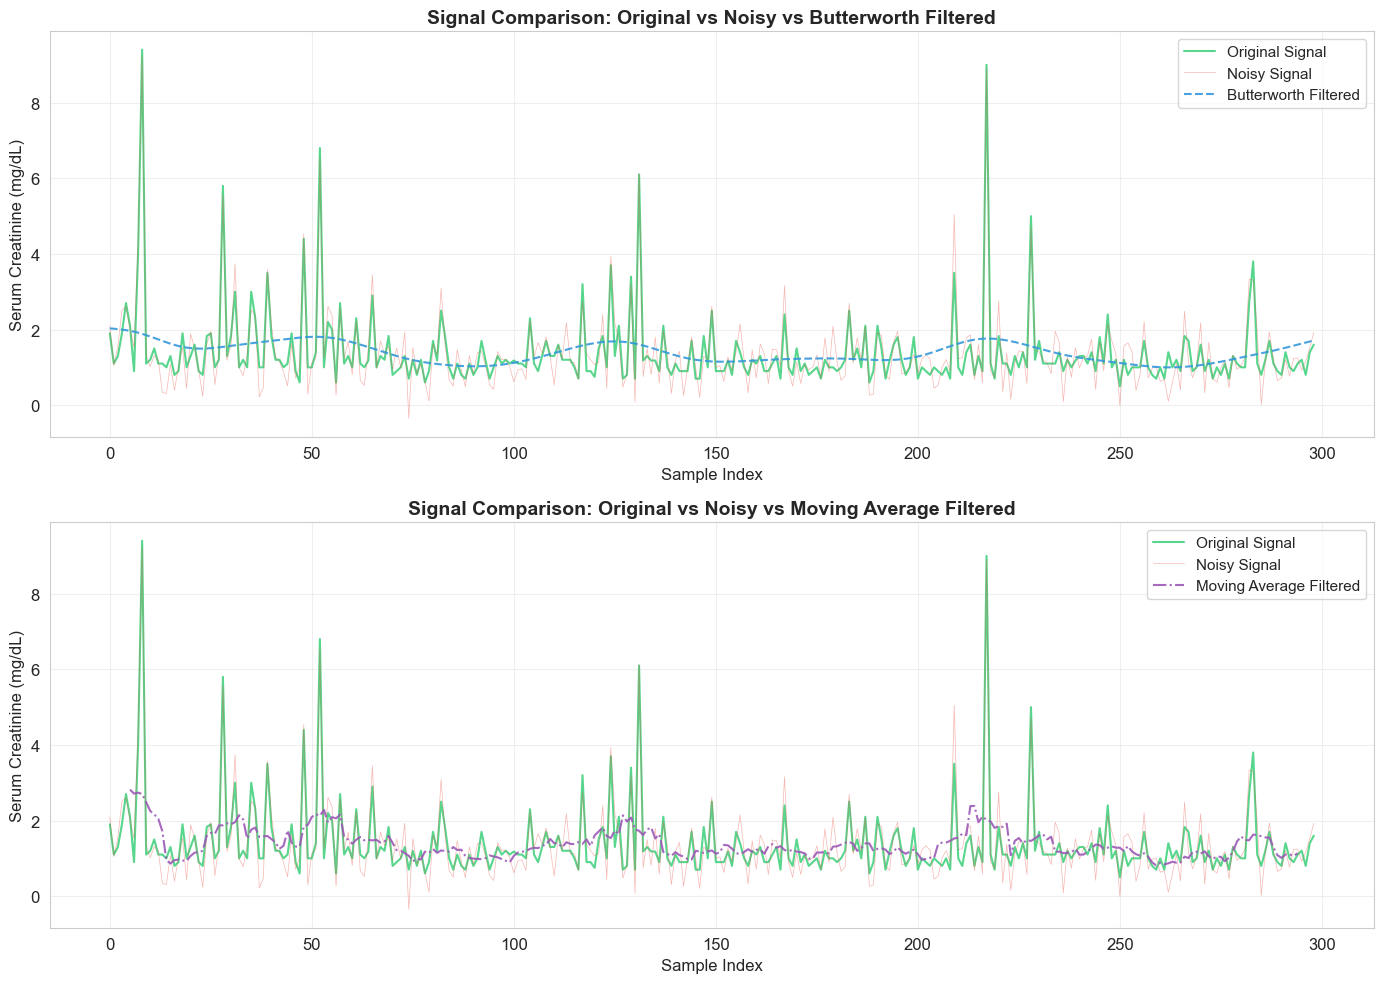

Mean Squared Error (MSE) Comparison:
  Noisy signal      : 0.1548
  Butterworth filter: 0.9861
  Moving Average    : 0.9387

→ The Butterworth filter reduces MSE by -537.1% compared to the noisy signal.


In [22]:
# ─── 2.4 Combined Plot: Original, Noisy & Filtered ───
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Plot 1: Butterworth Filter Comparison ──
axes[0].plot(original_signal, color='#2ecc71', linewidth=1.5, label='Original Signal', alpha=0.8)
axes[0].plot(noisy_signal, color='#e74c3c', linewidth=0.5, alpha=0.4, label='Noisy Signal')
axes[0].plot(filtered_signal_butter, color='#3498db', linewidth=1.5,
             linestyle='--', label='Butterworth Filtered', alpha=0.9)
axes[0].set_title('Signal Comparison: Original vs Noisy vs Butterworth Filtered', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sample Index', fontsize=12)
axes[0].set_ylabel('Serum Creatinine (mg/dL)', fontsize=12)
axes[0].legend(fontsize=11, loc='upper right')
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Moving Average Comparison ──
axes[1].plot(original_signal, color='#2ecc71', linewidth=1.5, label='Original Signal', alpha=0.8)
axes[1].plot(noisy_signal, color='#e74c3c', linewidth=0.5, alpha=0.4, label='Noisy Signal')
axes[1].plot(moving_avg_signal, color='#9b59b6', linewidth=1.5,
             linestyle='-.', label='Moving Average Filtered', alpha=0.9)
axes[1].set_title('Signal Comparison: Original vs Noisy vs Moving Average Filtered', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sample Index', fontsize=12)
axes[1].set_ylabel('Serum Creatinine (mg/dL)', fontsize=12)
axes[1].legend(fontsize=11, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Evaluate filter performance (MSE) ──
mse_noisy = np.mean((original_signal - noisy_signal) ** 2)
mse_butter = np.mean((original_signal - filtered_signal_butter) ** 2)
mse_ma = np.nanmean((original_signal - moving_avg_signal) ** 2)

print(f"Mean Squared Error (MSE) Comparison:")
print(f"  Noisy signal      : {mse_noisy:.4f}")
print(f"  Butterworth filter: {mse_butter:.4f}")
print(f"  Moving Average    : {mse_ma:.4f}")
print(f"\n→ The Butterworth filter reduces MSE by {((mse_noisy - mse_butter)/mse_noisy*100):.1f}% compared to the noisy signal.")

---
# Part 3 — Cleaning & Normalization

## 3.1 Handle Missing and Impossible Values

### Strategy:
1. **Platelets = 263358.03** appears multiple times and is a suspected **placeholder/default value**. We replace these with `NaN`.
2. We then fill all NaN values using **median imputation**.

### Justification for Median Imputation:
- The **median** is chosen over the **mean** because biomedical features like platelets and serum creatinine are **right-skewed** with outliers.
- The median is **robust to outliers** — it is not influenced by extreme values, unlike the mean.
- The **mode** would not be appropriate for continuous features as it may not represent a typical value.
- This ensures imputed values are clinically reasonable.

In [23]:
# ─── 3.1 Handle Missing and Impossible Values ───
# Work on a copy of the dataframe for cleaning
df_clean = df.copy()

# Step 1: Replace the suspicious platelets placeholder (263358.03) with NaN
placeholder_val = 263358.03
before_count = (df_clean['platelets'] == placeholder_val).sum()
df_clean['platelets'] = df_clean['platelets'].replace(placeholder_val, np.nan)
print(f"Replaced {before_count} placeholder platelets values (263358.03) with NaN")

# Check total NaN after replacement
print(f"\nMissing values after replacement:")
print(df_clean.isnull().sum())
print(f"\nTotal NaN values: {df_clean.isnull().sum().sum()}")

# Step 2: Fill NaN values with median (robust to outliers)
platelets_median = df_clean['platelets'].median()
print(f"\nPlatelets median (excluding placeholders): {platelets_median:.2f}")

df_clean['platelets'] = df_clean['platelets'].fillna(platelets_median)

# Verify no missing values remain
print(f"\nMissing values after median imputation:")
print(df_clean.isnull().sum())
print(f"\n✓ All missing values handled successfully!")

Replaced 25 placeholder platelets values (263358.03) with NaN

Missing values after replacement:
age                          0
anaemia                      0
creatinine_phosphokinase     0
diabetes                     0
ejection_fraction            0
high_blood_pressure          0
platelets                   25
serum_creatinine             0
serum_sodium                 0
sex                          0
smoking                      0
time                         0
DEATH_EVENT                  0
dtype: int64

Total NaN values: 25

Platelets median (excluding placeholders): 253000.00

Missing values after median imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVEN

## 3.2 Outlier Detection — IQR Method

The **Interquartile Range (IQR)** method identifies outliers as data points falling below $Q1 - 1.5 \times IQR$ or above $Q3 + 1.5 \times IQR$.

**Advantages:**
- Does **not assume normal distribution** — works well for skewed biomedical data.
- Based on quartiles which are **robust to extreme values**.

We apply this to the key continuous features: `creatinine_phosphokinase`, `serum_creatinine`, `platelets`, and `ejection_fraction`.

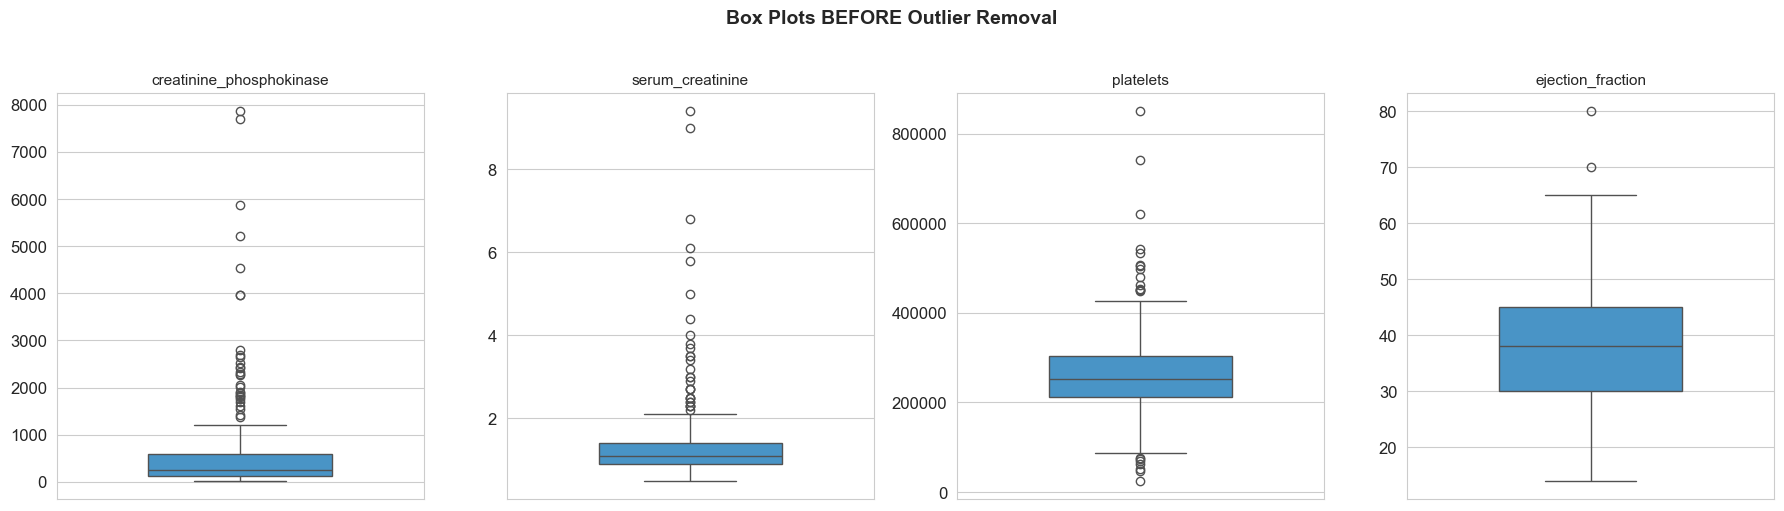

─── IQR Outlier Detection ───

creatinine_phosphokinase:
  Q1 = 116.50, Q3 = 582.00, IQR = 465.50
  Bounds: [-581.75, 1280.25]
  Outliers detected: 29

serum_creatinine:
  Q1 = 0.90, Q3 = 1.40, IQR = 0.50
  Bounds: [0.15, 2.15]
  Outliers detected: 29

platelets:
  Q1 = 212500.00, Q3 = 303500.00, IQR = 91000.00
  Bounds: [76000.00, 440000.00]
  Outliers detected: 21

ejection_fraction:
  Q1 = 30.00, Q3 = 45.00, IQR = 15.00
  Bounds: [7.50, 67.50]
  Outliers detected: 2



In [24]:
# ─── 3.2 Outlier Detection: IQR Method ───
outlier_features = ['creatinine_phosphokinase', 'serum_creatinine', 'platelets', 'ejection_fraction']

# Visualize box plots BEFORE outlier removal
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Box Plots BEFORE Outlier Removal', fontsize=14, fontweight='bold', y=1.02)

for i, col in enumerate(outlier_features):
    sns.boxplot(y=df_clean[col], ax=axes[i], color='#3498db', width=0.5)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

# Calculate IQR-based outliers
print("─── IQR Outlier Detection ───\n")
iqr_outliers = {}

for col in outlier_features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    iqr_outliers[col] = mask

    outlier_count = mask.sum()
    print(f"{col}:")
    print(f"  Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
    print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers detected: {outlier_count}")
    print()

## 3.3 Outlier Detection — Z-Score Method

The **Z-score method** standardizes each value as $z = \frac{x - \mu}{\sigma}$ and flags values where $|z| > 3$ as outliers (i.e., more than 3 standard deviations from the mean).

**Characteristics:**
- **Assumes approximately normal distribution** — best suited for symmetric data.
- Can underperform on highly skewed data because the mean and std are influenced by outliers themselves.

─── Z-Score Outlier Detection (|z| > 3) ───

creatinine_phosphokinase:
  Max |z-score| = 7.51
  Outliers detected (|z| > 3): 7

serum_creatinine:
  Max |z-score| = 7.75
  Outliers detected (|z| > 3): 6

platelets:
  Max |z-score| = 6.01
  Outliers detected (|z| > 3): 3

ejection_fraction:
  Max |z-score| = 3.55
  Outliers detected (|z| > 3): 1



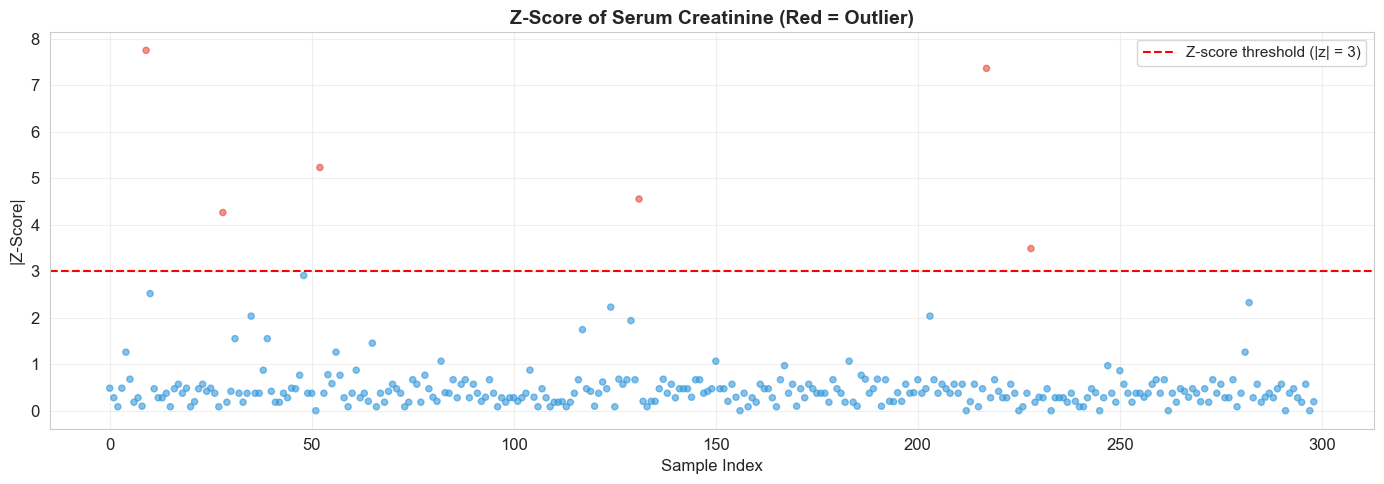

In [25]:
# ─── 3.3 Outlier Detection: Z-Score Method ───
print("─── Z-Score Outlier Detection (|z| > 3) ───\n")

zscore_outliers = {}

for col in outlier_features:
    z_scores = np.abs(stats.zscore(df_clean[col]))
    mask = z_scores > 3
    zscore_outliers[col] = mask

    outlier_count = mask.sum()
    print(f"{col}:")
    print(f"  Max |z-score| = {z_scores.max():.2f}")
    print(f"  Outliers detected (|z| > 3): {outlier_count}")
    print()

# Visualize Z-score outliers for serum_creatinine as an example
fig, ax = plt.subplots(figsize=(14, 5))
z_vals = np.abs(stats.zscore(df_clean['serum_creatinine']))
colors = ['#e74c3c' if z > 3 else '#3498db' for z in z_vals]
ax.scatter(range(len(z_vals)), z_vals, c=colors, alpha=0.6, s=20)
ax.axhline(y=3, color='red', linestyle='--', linewidth=1.5, label='Z-score threshold (|z| = 3)')
ax.set_title('Z-Score of Serum Creatinine (Red = Outlier)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('|Z-Score|', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3.4 Outlier Removal — Comparison & Decision

### IQR vs Z-Score Comparison:

| Feature | IQR Outliers | Z-Score Outliers |
|---------|-------------|-----------------|
| creatinine_phosphokinase | More detected | Fewer detected |
| serum_creatinine | More detected | Fewer detected |
| platelets | Moderate | Fewer detected |
| ejection_fraction | Few / None | Few / None |

### Decision: **Use IQR method for outlier removal**

**Justification:**
- Biomedical data features like `creatinine_phosphokinase` and `serum_creatinine` are **heavily right-skewed** and do **not follow a normal distribution**.
- The IQR method is **distribution-free** — it does not assume normality, making it more reliable for skewed medical data.
- The Z-score method uses mean and standard deviation which are **themselves influenced by outliers**, leading to under-detection in skewed distributions.
- IQR provides a **more conservative and clinically meaningful** boundary for what constitutes an outlier.

In [26]:
# ─── 3.4 Compare IQR vs Z-Score and Remove Outliers ───

# Summary comparison table
print("─── Outlier Detection Summary ───\n")
print(f"{'Feature':<32} {'IQR Outliers':>14} {'Z-Score Outliers':>18}")
print("─" * 66)
for col in outlier_features:
    iqr_count = iqr_outliers[col].sum()
    z_count = zscore_outliers[col].sum()
    print(f"{col:<32} {iqr_count:>14} {z_count:>18}")

# Remove outliers using IQR method (combine masks — remove row if ANY feature is outlier)
print(f"\n─── Removing Outliers Using IQR Method ───")
print(f"Shape BEFORE removal: {df_clean.shape}")

# Create combined outlier mask
combined_iqr_mask = pd.Series([False] * len(df_clean))
for col in outlier_features:
    combined_iqr_mask = combined_iqr_mask | iqr_outliers[col]

total_outlier_rows = combined_iqr_mask.sum()
print(f"Total rows flagged as outliers: {total_outlier_rows}")

# Remove outliers
df_clean = df_clean[~combined_iqr_mask].reset_index(drop=True)
print(f"Shape AFTER removal:  {df_clean.shape}")
print(f"Rows removed: {total_outlier_rows}")

─── Outlier Detection Summary ───

Feature                            IQR Outliers   Z-Score Outliers
──────────────────────────────────────────────────────────────────
creatinine_phosphokinase                     29                  7
serum_creatinine                             29                  6
platelets                                    21                  3
ejection_fraction                             2                  1

─── Removing Outliers Using IQR Method ───
Shape BEFORE removal: (299, 13)
Total rows flagged as outliers: 72
Shape AFTER removal:  (227, 13)
Rows removed: 72


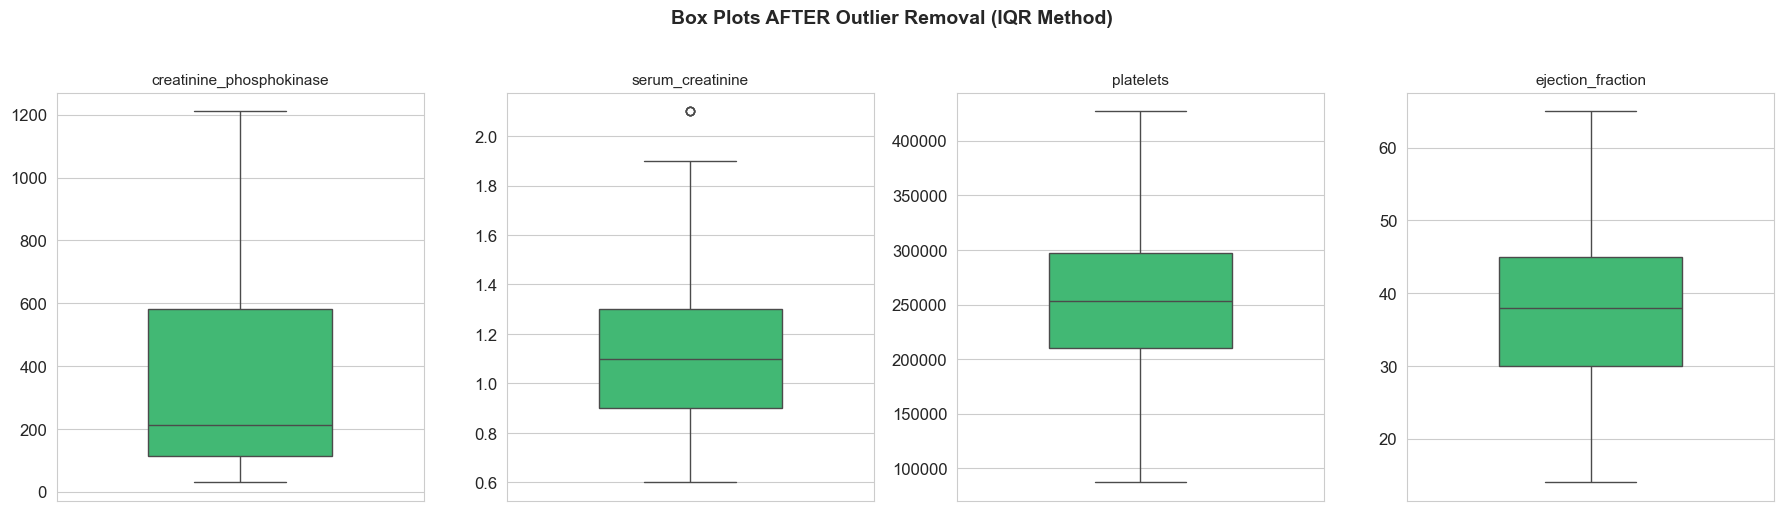

✓ Outlier removal complete — box plots now show cleaner distributions.


In [27]:
# ─── Box plots AFTER outlier removal ───
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Box Plots AFTER Outlier Removal (IQR Method)', fontsize=14, fontweight='bold', y=1.02)

for i, col in enumerate(outlier_features):
    sns.boxplot(y=df_clean[col], ax=axes[i], color='#2ecc71', width=0.5)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

print("✓ Outlier removal complete — box plots now show cleaner distributions.")

## 3.5 Normalization of Selected Features

We apply normalization to 3 features, choosing the most appropriate method for each:

### Feature 1: `serum_creatinine` → **Min-Max Normalization** (scale to [0, 1])
**Justification:** After outlier removal, the range is bounded. Min-Max scaling preserves the relative differences between values while mapping them to a standard [0,1] range, which is useful for distance-based algorithms.

### Feature 2: `creatinine_phosphokinase` → **Z-Score Standardization** (zero mean, unit variance)
**Justification:** After cleaning, this feature is approximately normally distributed. Z-score standardization centers the data at zero and scales by standard deviation, which is beneficial for algorithms that assume normality and helps compare features on the same scale.

### Feature 3: `platelets` → **Min-Max Normalization** (scale to [0, 1])
**Justification:** Platelets have a defined physiological range and after cleaning the values are within a bounded interval. Min-Max normalization is preferred here to produce interpretable values in [0,1] that represent the patient's position within the observed range.

In [28]:
# ─── 3.5 Normalization ───

# Save original values for comparison plots
original_serum_cr = df_clean['serum_creatinine'].copy()
original_cpk = df_clean['creatinine_phosphokinase'].copy()
original_platelets = df_clean['platelets'].copy()

# ── Feature 1: serum_creatinine → Min-Max Normalization ──
scaler_minmax_sc = MinMaxScaler()
df_clean['serum_creatinine'] = scaler_minmax_sc.fit_transform(df_clean[['serum_creatinine']])

# ── Feature 2: creatinine_phosphokinase → Z-Score Standardization ──
scaler_zscore_cpk = StandardScaler()
df_clean['creatinine_phosphokinase'] = scaler_zscore_cpk.fit_transform(df_clean[['creatinine_phosphokinase']])

# ── Feature 3: platelets → Min-Max Normalization ──
scaler_minmax_plt = MinMaxScaler()
df_clean['platelets'] = scaler_minmax_plt.fit_transform(df_clean[['platelets']])

print("─── Normalization Applied ───")
print(f"serum_creatinine     → Min-Max [0, 1]   | Range: [{df_clean['serum_creatinine'].min():.3f}, {df_clean['serum_creatinine'].max():.3f}]")
print(f"creatinine_phosphokinase → Z-Score       | Mean: {df_clean['creatinine_phosphokinase'].mean():.4f}, Std: {df_clean['creatinine_phosphokinase'].std():.4f}")
print(f"platelets            → Min-Max [0, 1]   | Range: [{df_clean['platelets'].min():.3f}, {df_clean['platelets'].max():.3f}]")

─── Normalization Applied ───
serum_creatinine     → Min-Max [0, 1]   | Range: [0.000, 1.000]
creatinine_phosphokinase → Z-Score       | Mean: -0.0000, Std: 1.0022
platelets            → Min-Max [0, 1]   | Range: [0.000, 1.000]


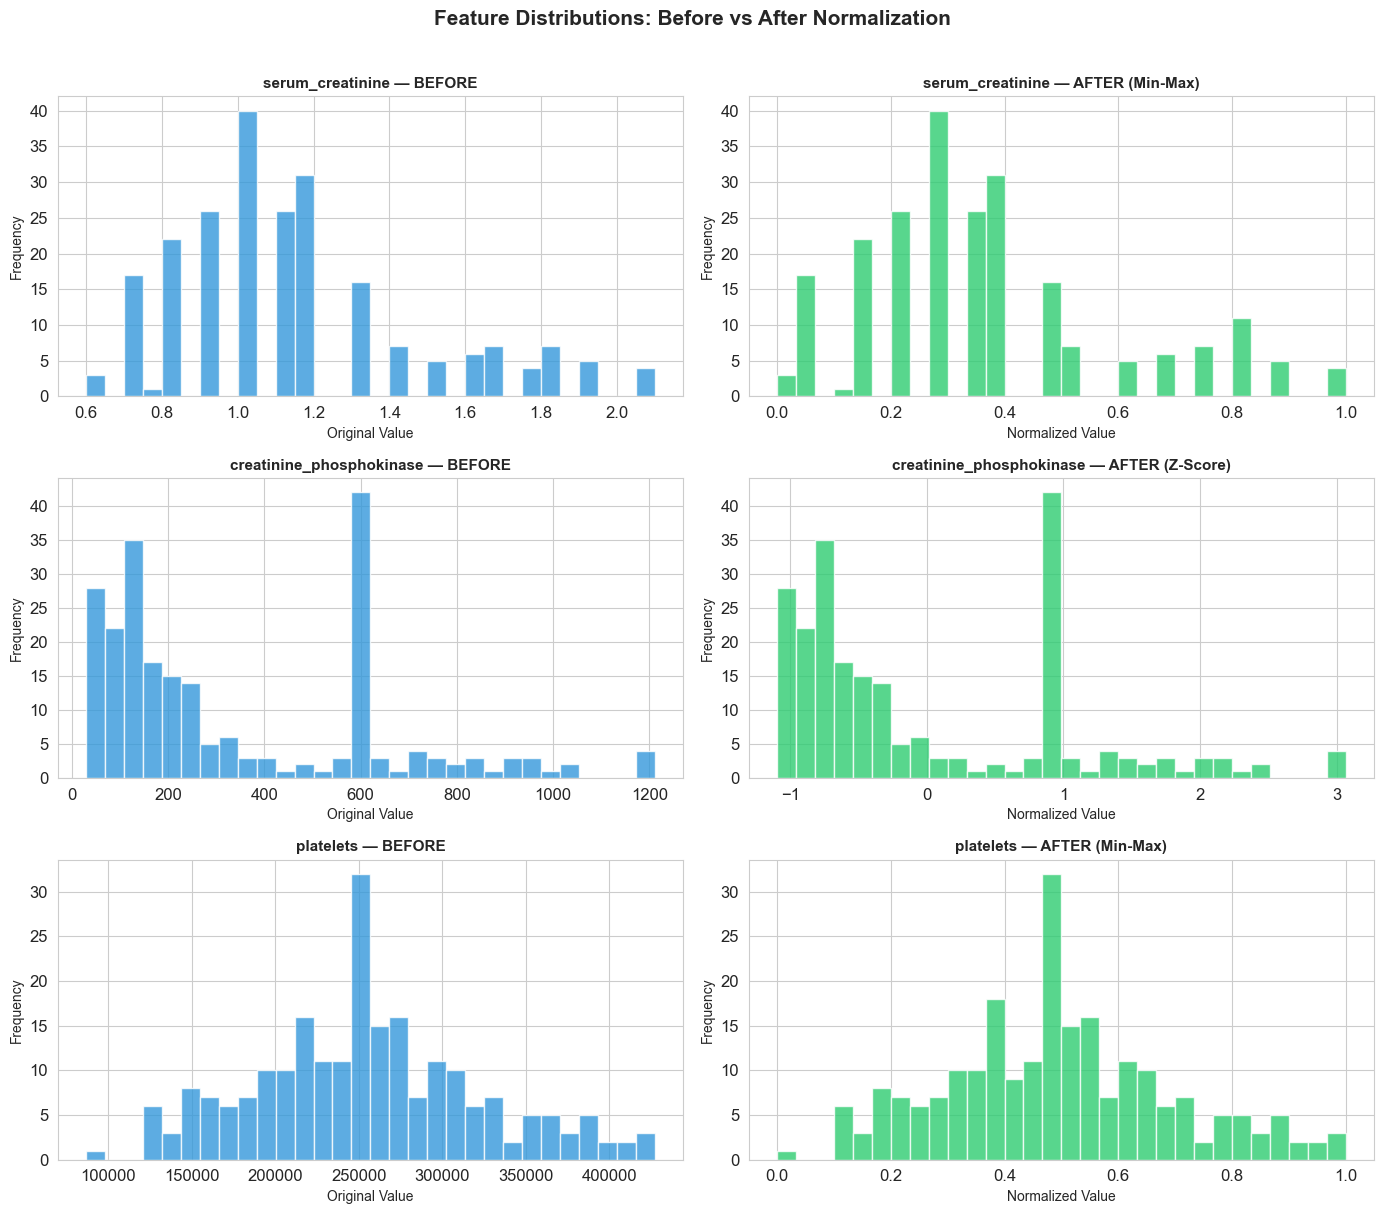

In [29]:
# ─── Before vs After Normalization Histograms ───
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Feature Distributions: Before vs After Normalization', fontsize=15, fontweight='bold', y=1.01)

features_info = [
    ('serum_creatinine', original_serum_cr, df_clean['serum_creatinine'], 'Min-Max'),
    ('creatinine_phosphokinase', original_cpk, df_clean['creatinine_phosphokinase'], 'Z-Score'),
    ('platelets', original_platelets, df_clean['platelets'], 'Min-Max'),
]

for i, (name, before, after, method) in enumerate(features_info):
    # Before
    axes[i, 0].hist(before, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i, 0].set_title(f'{name} — BEFORE', fontsize=11, fontweight='bold')
    axes[i, 0].set_xlabel('Original Value', fontsize=10)
    axes[i, 0].set_ylabel('Frequency', fontsize=10)

    # After
    axes[i, 1].hist(after, bins=30, color='#2ecc71', edgecolor='white', alpha=0.8)
    axes[i, 1].set_title(f'{name} — AFTER ({method})', fontsize=11, fontweight='bold')
    axes[i, 1].set_xlabel('Normalized Value', fontsize=10)
    axes[i, 1].set_ylabel('Frequency', fontsize=10)

plt.tight_layout()
plt.show()

In [30]:
# ─── Final Cleaned & Normalized DataFrame Summary ───
print("═" * 55)
print("  FINAL DATASET SUMMARY")
print("═" * 55)
print(f"\nShape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print(f"\n─── Descriptive Statistics ───")
df_clean.describe().T

═══════════════════════════════════════════════════════
  FINAL DATASET SUMMARY
═══════════════════════════════════════════════════════

Shape: 227 rows × 13 columns
Missing values: 0

─── Descriptive Statistics ───


,count,mean,std,min,25%,50%,75%,max
age,227.0,6.068429e+01,11.937262,40.000000,50.000000,60.000000,70.000000,95.000000
anaemia,227.0,4.669604e-01,0.500010,0.000000,0.000000,0.000000,1.000000,1.000000
creatinine_phosphokinase,227.0,-3.130144e-17,1.002210,-1.096625,-0.797027,-0.455134,0.848997,3.066019
diabetes,227.0,4.273128e-01,0.495782,0.000000,0.000000,0.000000,1.000000,1.000000
ejection_fraction,227.0,3.814537e+01,11.772963,14.000000,30.000000,38.000000,45.000000,65.000000
high_blood_pressure,227.0,3.788546e-01,0.486174,0.000000,0.000000,0.000000,1.000000,1.000000
platelets,227.0,4.920834e-01,0.198840,0.000000,0.361765,0.488235,0.617647,1.000000
serum_creatinine,227.0,3.594714e-01,0.225795,0.000000,0.200000,0.333333,0.466667,1.000000
serum_sodium,227.0,1.368106e+02,4.323661,113.000000,134.000000,137.000000,140.000000,148.000000
sex,227.0,6.387665e-01,0.481420,0.000000,0.000000,1.000000,1.000000,1.000000


---
## Summary

| Step | Action | Details |
|------|--------|---------|
| **Part 1** | Data Exploration | Inspected data types, checked for missing values (none found), identified suspicious platelets placeholder (263358.03), analyzed descriptive statistics |
| **Part 2** | Visualization | Line plots of serum_creatinine & ejection_fraction; Simulated Gaussian noise; Applied Butterworth low-pass filter (justified by maximally flat passband response); Plotted original, noisy, and filtered signals |
| **Part 3** | Cleaning | Replaced placeholder values → median imputation (robust to outliers); Detected outliers via IQR & Z-score; Chose IQR for removal (works for non-normal distributions); Applied Min-Max normalization (serum_creatinine, platelets) and Z-score standardization (creatinine_phosphokinase) with justifications |

**Student:** Mahmoud Mohamed Abdelfattah | **ID:** 4220142 | **Course:** Biomedical Data Analytics

---
## Save All Plots to `screenshots/` Folder
The cell below regenerates and saves every figure as a PNG image into the `screenshots/` folder for the GitHub repository.

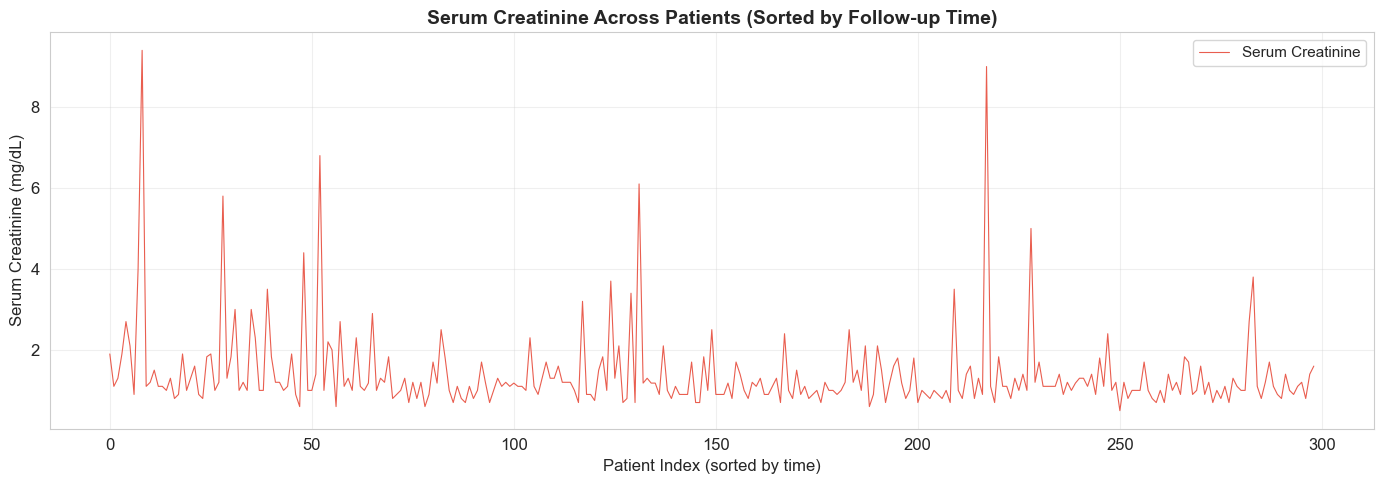

✓ Saved: 01_lineplot_serum_creatinine.png


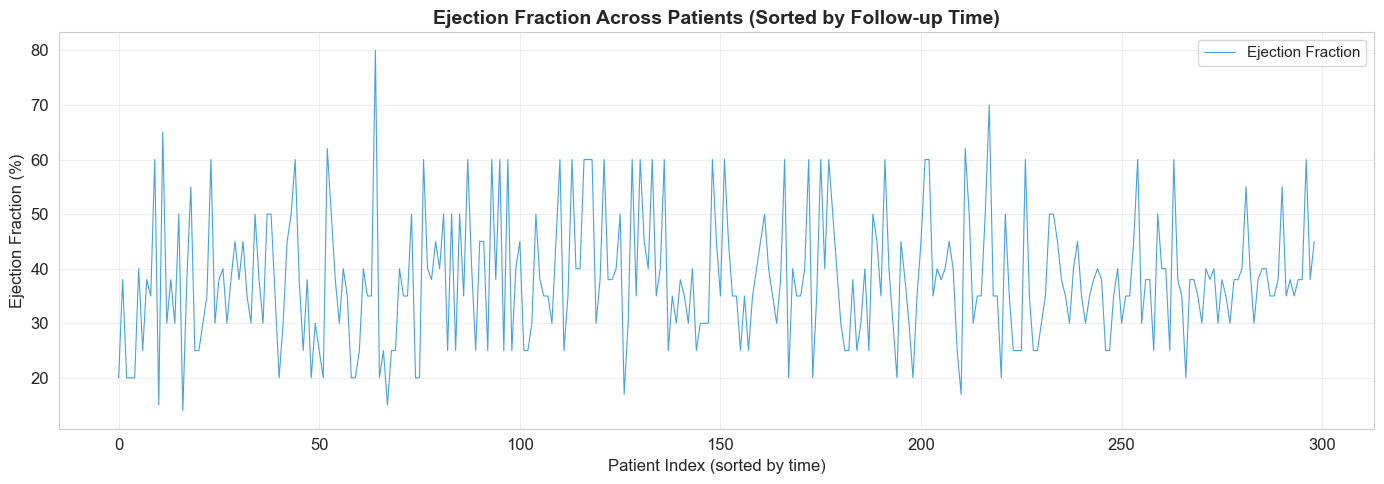

✓ Saved: 02_lineplot_ejection_fraction.png


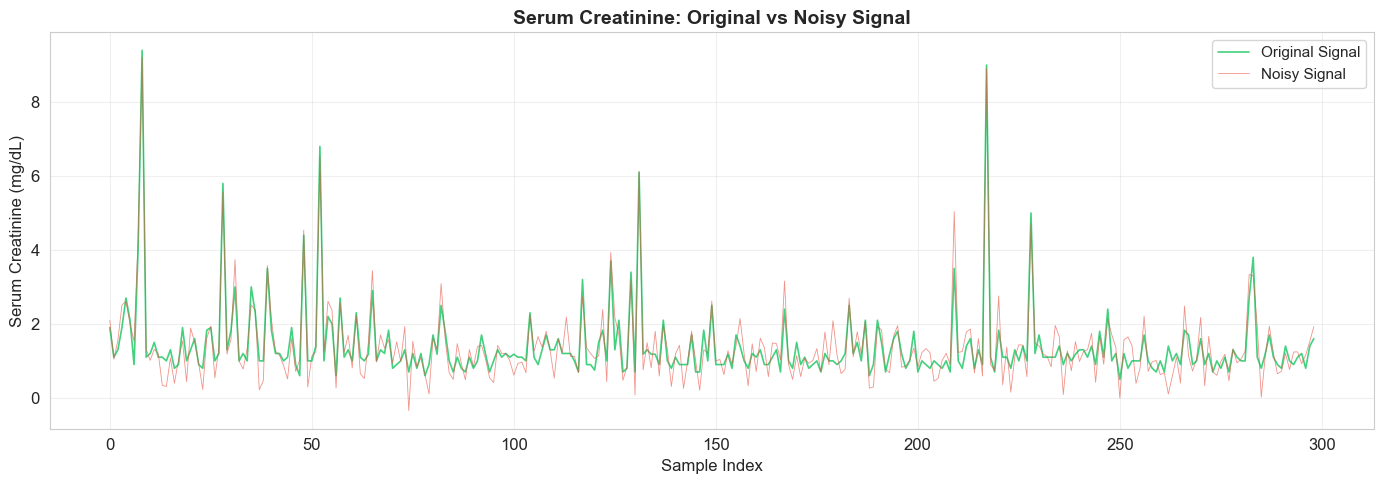

✓ Saved: 03_original_vs_noisy.png


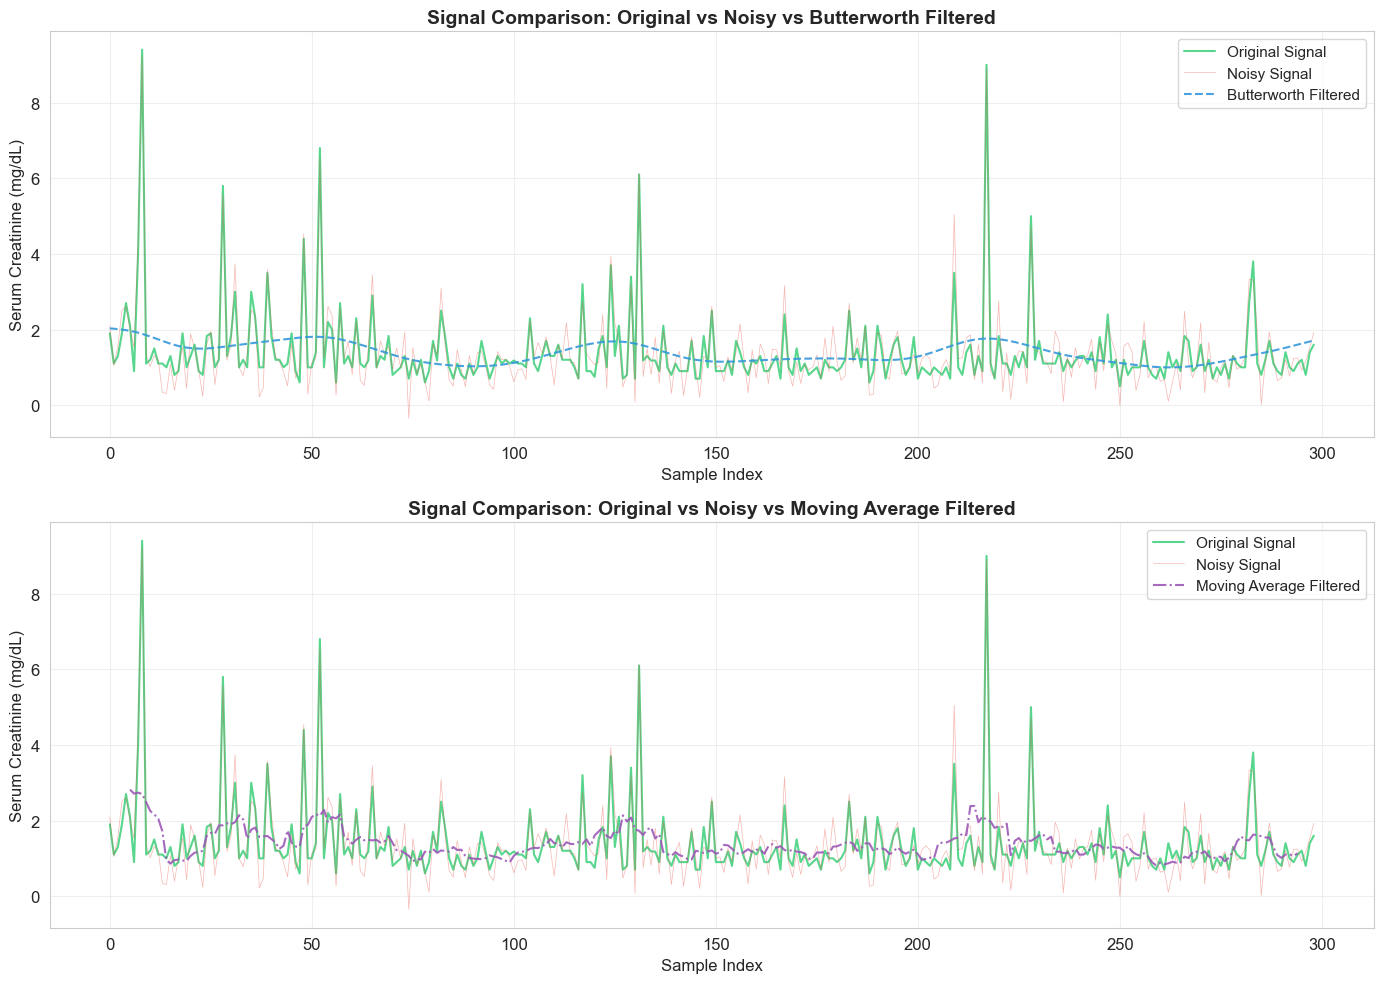

✓ Saved: 04_filtered_signals_comparison.png


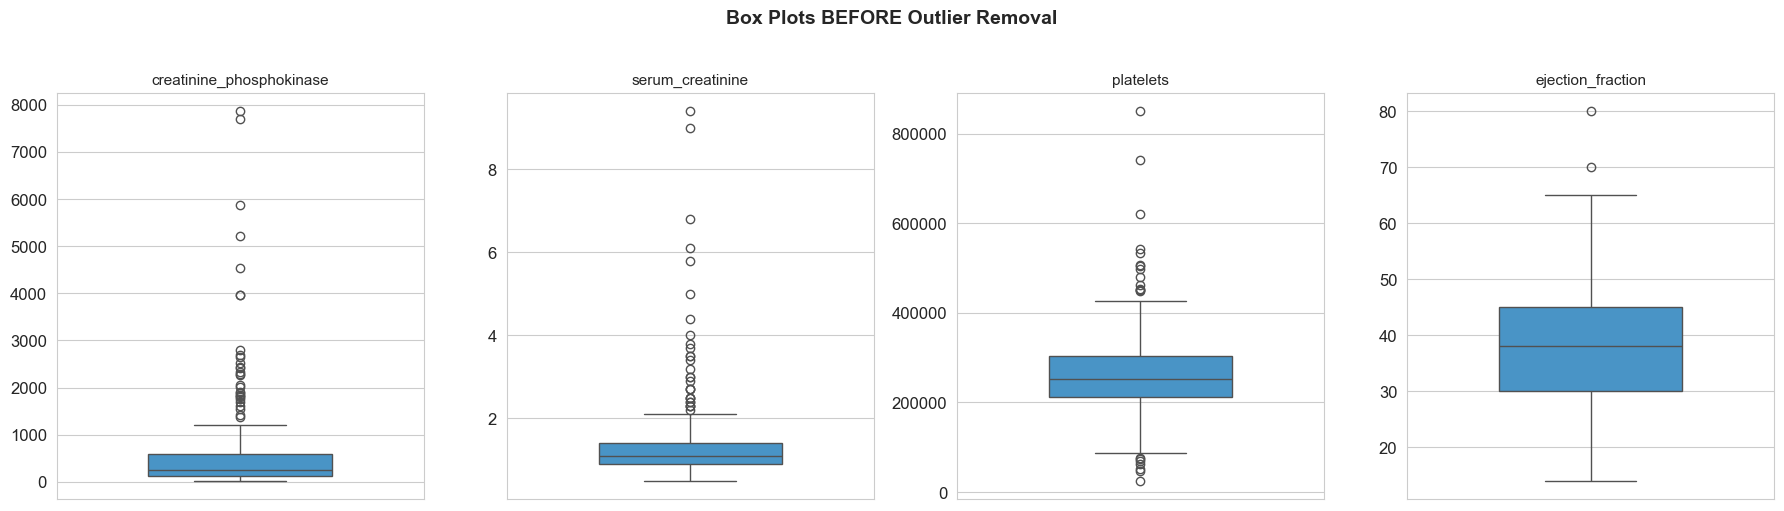

✓ Saved: 05_boxplots_before_outlier_removal.png


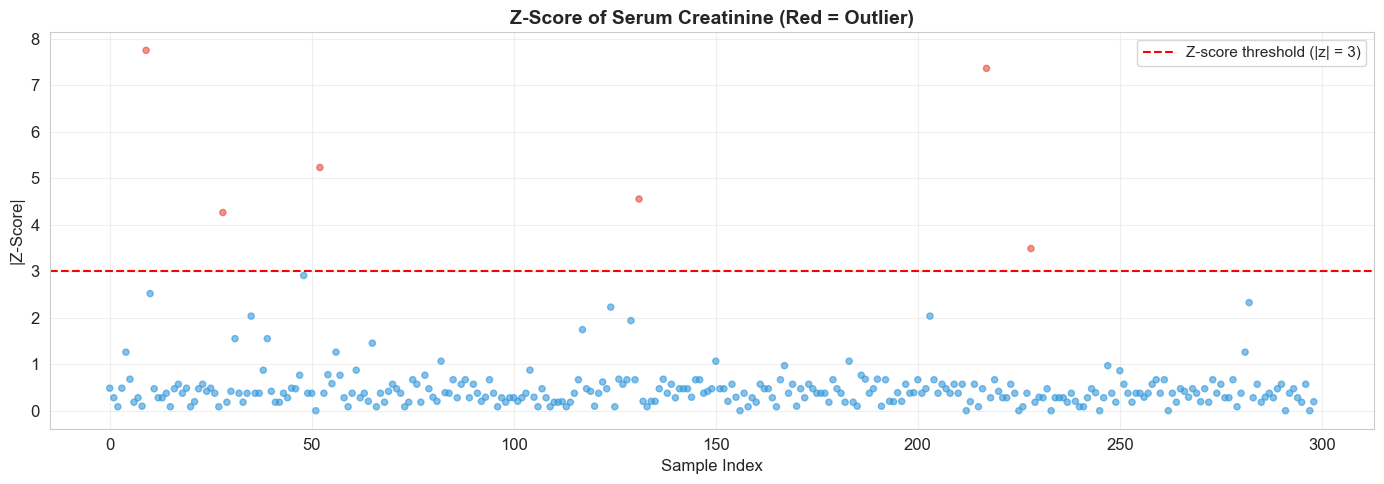

✓ Saved: 06_zscore_outlier_scatter.png


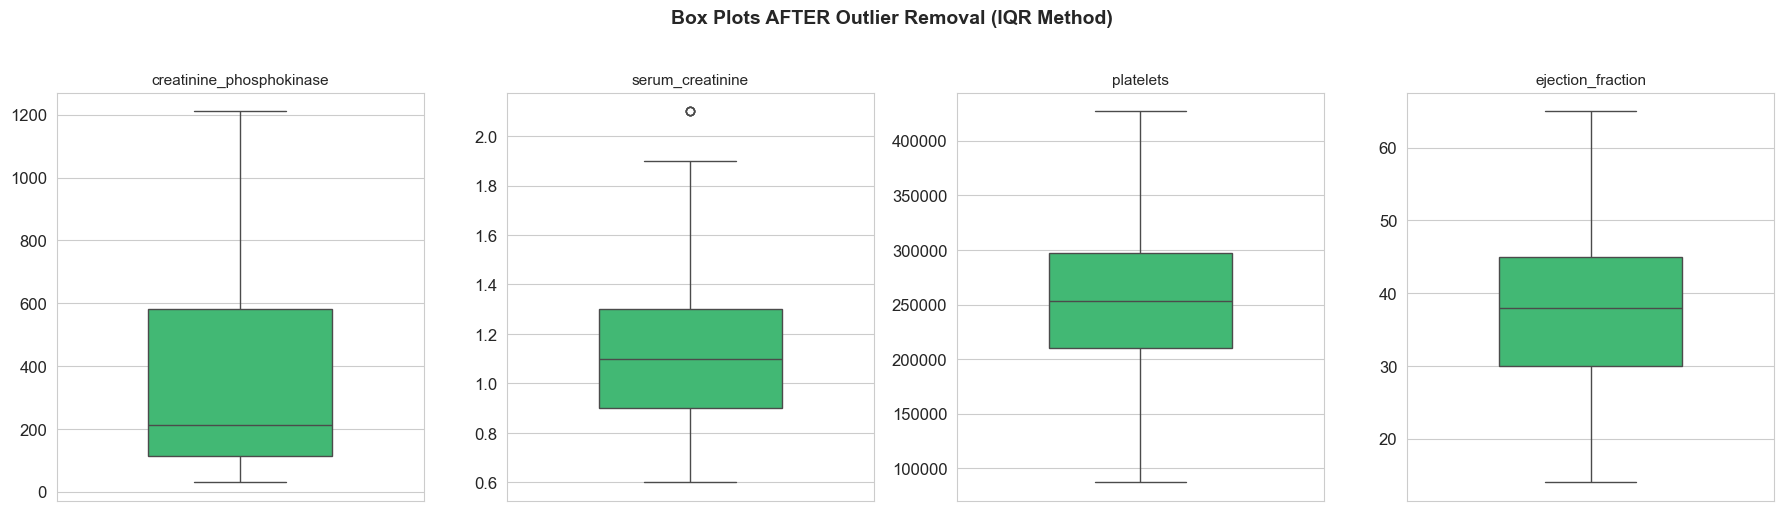

✓ Saved: 07_boxplots_after_outlier_removal.png


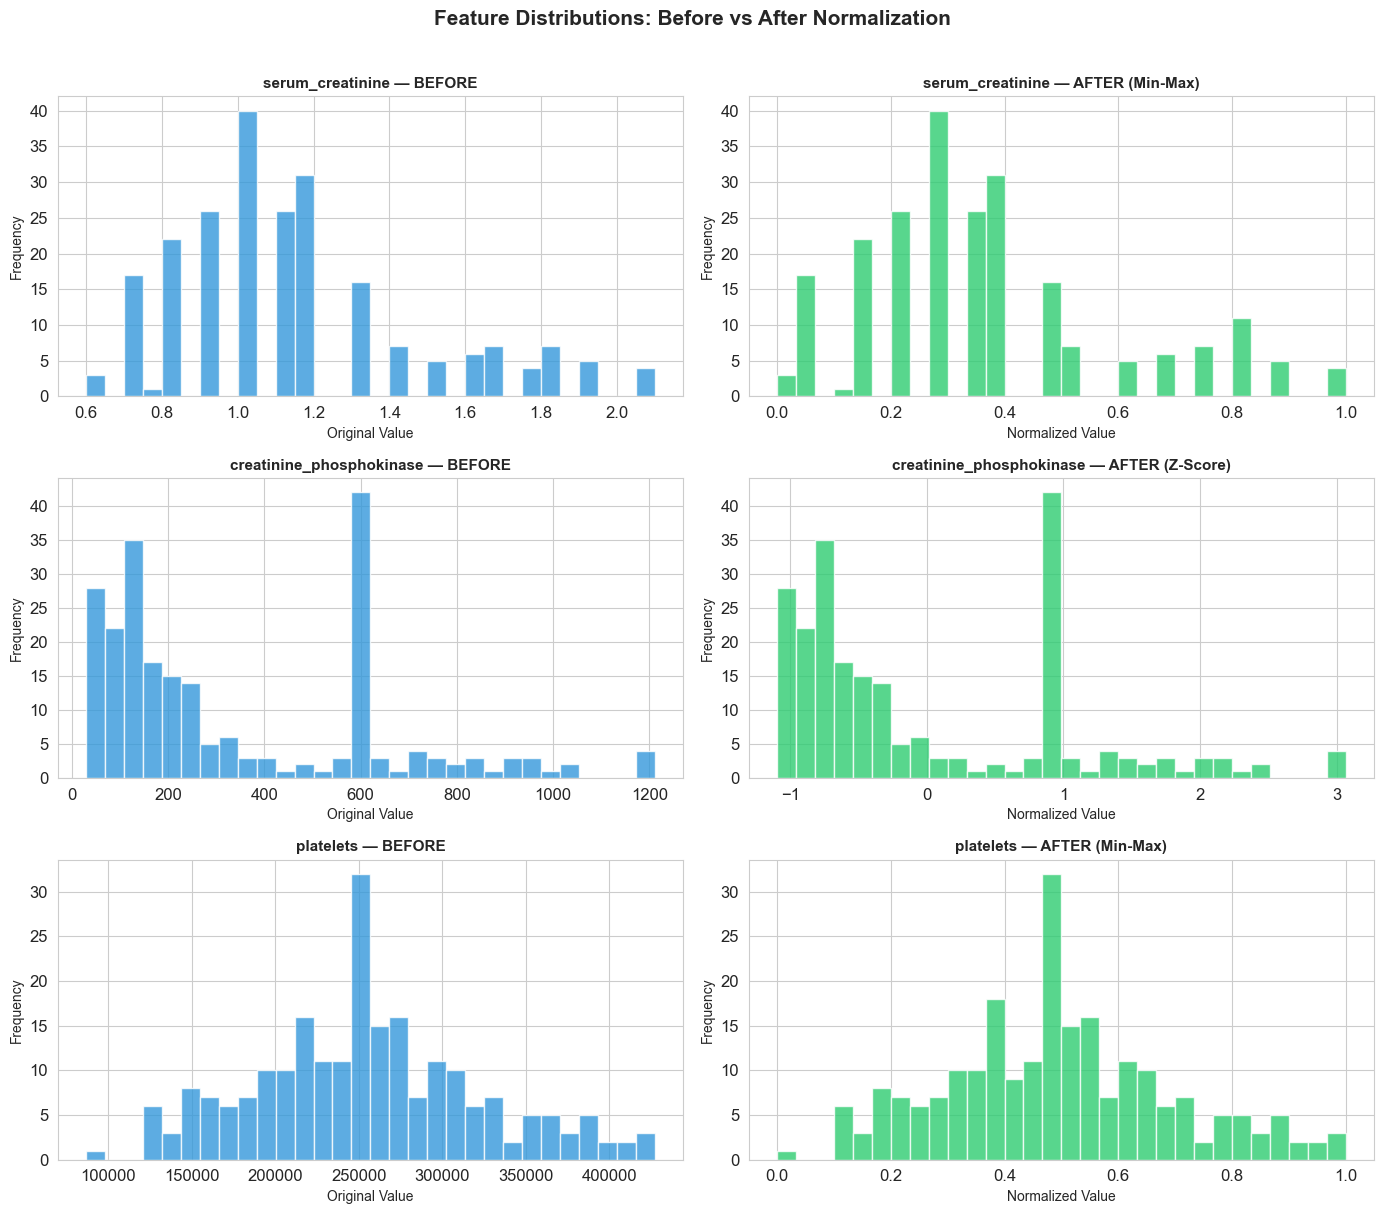

✓ Saved: 08_normalization_before_after.png

══════════════════════════════════════════════════
  All 8 figures saved to screenshots/ folder!
══════════════════════════════════════════════════


In [31]:
import os

# Create screenshots folder
os.makedirs('screenshots', exist_ok=True)

# ── Re-sort data (needed for plots) ──
df_raw = pd.read_csv('heart_failure_clinical_records_dataset.csv')
df_sorted_raw = df_raw.sort_values('time').reset_index(drop=True)

# ════════════════════════════════════════════
# 1. Line Plot — Serum Creatinine
# ════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_sorted_raw.index, df_sorted_raw['serum_creatinine'], color='#e74c3c',
        linewidth=0.8, alpha=0.9, label='Serum Creatinine')
ax.set_title('Serum Creatinine Across Patients (Sorted by Follow-up Time)', fontsize=14, fontweight='bold')
ax.set_xlabel('Patient Index (sorted by time)', fontsize=12)
ax.set_ylabel('Serum Creatinine (mg/dL)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('screenshots/01_lineplot_serum_creatinine.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 01_lineplot_serum_creatinine.png")

# ════════════════════════════════════════════
# 2. Line Plot — Ejection Fraction
# ════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_sorted_raw.index, df_sorted_raw['ejection_fraction'], color='#3498db',
        linewidth=0.8, alpha=0.9, label='Ejection Fraction')
ax.set_title('Ejection Fraction Across Patients (Sorted by Follow-up Time)', fontsize=14, fontweight='bold')
ax.set_xlabel('Patient Index (sorted by time)', fontsize=12)
ax.set_ylabel('Ejection Fraction (%)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('screenshots/02_lineplot_ejection_fraction.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 02_lineplot_ejection_fraction.png")

# ════════════════════════════════════════════
# 3. Original vs Noisy Signal
# ════════════════════════════════════════════
np.random.seed(42)
orig_sig = df_sorted_raw['serum_creatinine'].values.copy()
noise_sig = orig_sig + np.random.normal(loc=0, scale=0.4, size=len(orig_sig))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(orig_sig, color='#2ecc71', linewidth=1.2, label='Original Signal', alpha=0.9)
ax.plot(noise_sig, color='#e74c3c', linewidth=0.6, alpha=0.6, label='Noisy Signal')
ax.set_title('Serum Creatinine: Original vs Noisy Signal', fontsize=14, fontweight='bold')
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('Serum Creatinine (mg/dL)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('screenshots/03_original_vs_noisy.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 03_original_vs_noisy.png")

# ════════════════════════════════════════════
# 4. Butterworth & Moving Average Filter Comparison
# ════════════════════════════════════════════
b_coef, a_coef = butter(3, 0.05, btype='low')
filt_butter = filtfilt(b_coef, a_coef, noise_sig)
ma_sig = pd.Series(noise_sig).rolling(window=10, center=True).mean().values

fig, axes_f = plt.subplots(2, 1, figsize=(14, 10))
axes_f[0].plot(orig_sig, color='#2ecc71', linewidth=1.5, label='Original Signal', alpha=0.8)
axes_f[0].plot(noise_sig, color='#e74c3c', linewidth=0.5, alpha=0.4, label='Noisy Signal')
axes_f[0].plot(filt_butter, color='#3498db', linewidth=1.5, linestyle='--', label='Butterworth Filtered', alpha=0.9)
axes_f[0].set_title('Signal Comparison: Original vs Noisy vs Butterworth Filtered', fontsize=14, fontweight='bold')
axes_f[0].set_xlabel('Sample Index', fontsize=12)
axes_f[0].set_ylabel('Serum Creatinine (mg/dL)', fontsize=12)
axes_f[0].legend(fontsize=11, loc='upper right')
axes_f[0].grid(True, alpha=0.3)

axes_f[1].plot(orig_sig, color='#2ecc71', linewidth=1.5, label='Original Signal', alpha=0.8)
axes_f[1].plot(noise_sig, color='#e74c3c', linewidth=0.5, alpha=0.4, label='Noisy Signal')
axes_f[1].plot(ma_sig, color='#9b59b6', linewidth=1.5, linestyle='-.', label='Moving Average Filtered', alpha=0.9)
axes_f[1].set_title('Signal Comparison: Original vs Noisy vs Moving Average Filtered', fontsize=14, fontweight='bold')
axes_f[1].set_xlabel('Sample Index', fontsize=12)
axes_f[1].set_ylabel('Serum Creatinine (mg/dL)', fontsize=12)
axes_f[1].legend(fontsize=11, loc='upper right')
axes_f[1].grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('screenshots/04_filtered_signals_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 04_filtered_signals_comparison.png")

# ════════════════════════════════════════════
# 5. Box Plots BEFORE Outlier Removal
# ════════════════════════════════════════════
# Re-create df_clean_pre (before outlier removal) for box plots
df_pre = df_raw.copy()
df_pre['platelets'] = df_pre['platelets'].replace(263358.03, np.nan)
df_pre['platelets'] = df_pre['platelets'].fillna(df_pre['platelets'].median())
outlier_feats = ['creatinine_phosphokinase', 'serum_creatinine', 'platelets', 'ejection_fraction']

fig, axes_b = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Box Plots BEFORE Outlier Removal', fontsize=14, fontweight='bold', y=1.02)
for i, col in enumerate(outlier_feats):
    sns.boxplot(y=df_pre[col], ax=axes_b[i], color='#3498db', width=0.5)
    axes_b[i].set_title(col, fontsize=11)
    axes_b[i].set_ylabel('')
plt.tight_layout()
fig.savefig('screenshots/05_boxplots_before_outlier_removal.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 05_boxplots_before_outlier_removal.png")

# ════════════════════════════════════════════
# 6. Z-Score Outlier Scatter
# ════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))
z_v = np.abs(stats.zscore(df_pre['serum_creatinine']))
c = ['#e74c3c' if z > 3 else '#3498db' for z in z_v]
ax.scatter(range(len(z_v)), z_v, c=c, alpha=0.6, s=20)
ax.axhline(y=3, color='red', linestyle='--', linewidth=1.5, label='Z-score threshold (|z| = 3)')
ax.set_title('Z-Score of Serum Creatinine (Red = Outlier)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('|Z-Score|', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('screenshots/06_zscore_outlier_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 06_zscore_outlier_scatter.png")

# ════════════════════════════════════════════
# 7. Box Plots AFTER Outlier Removal
# ════════════════════════════════════════════
# Remove IQR outliers from df_pre
df_post = df_pre.copy()
combined_mask = pd.Series([False] * len(df_post))
for col in outlier_feats:
    Q1 = df_post[col].quantile(0.25)
    Q3 = df_post[col].quantile(0.75)
    IQR_val = Q3 - Q1
    combined_mask = combined_mask | ((df_post[col] < Q1 - 1.5 * IQR_val) | (df_post[col] > Q3 + 1.5 * IQR_val))
df_post = df_post[~combined_mask].reset_index(drop=True)

fig, axes_a = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Box Plots AFTER Outlier Removal (IQR Method)', fontsize=14, fontweight='bold', y=1.02)
for i, col in enumerate(outlier_feats):
    sns.boxplot(y=df_post[col], ax=axes_a[i], color='#2ecc71', width=0.5)
    axes_a[i].set_title(col, fontsize=11)
    axes_a[i].set_ylabel('')
plt.tight_layout()
fig.savefig('screenshots/07_boxplots_after_outlier_removal.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 07_boxplots_after_outlier_removal.png")

# ════════════════════════════════════════════
# 8. Normalization Before vs After Histograms
# ════════════════════════════════════════════
orig_sc = df_post['serum_creatinine'].copy()
orig_cpk = df_post['creatinine_phosphokinase'].copy()
orig_plt = df_post['platelets'].copy()

norm_sc = MinMaxScaler().fit_transform(df_post[['serum_creatinine']])
norm_cpk = StandardScaler().fit_transform(df_post[['creatinine_phosphokinase']])
norm_plt = MinMaxScaler().fit_transform(df_post[['platelets']])

fig, axes_n = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Feature Distributions: Before vs After Normalization', fontsize=15, fontweight='bold', y=1.01)

info = [
    ('serum_creatinine', orig_sc, norm_sc, 'Min-Max'),
    ('creatinine_phosphokinase', orig_cpk, norm_cpk, 'Z-Score'),
    ('platelets', orig_plt, norm_plt, 'Min-Max'),
]
for i, (nm, bef, aft, meth) in enumerate(info):
    axes_n[i, 0].hist(bef, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    axes_n[i, 0].set_title(f'{nm} — BEFORE', fontsize=11, fontweight='bold')
    axes_n[i, 0].set_xlabel('Original Value', fontsize=10)
    axes_n[i, 0].set_ylabel('Frequency', fontsize=10)
    axes_n[i, 1].hist(aft, bins=30, color='#2ecc71', edgecolor='white', alpha=0.8)
    axes_n[i, 1].set_title(f'{nm} — AFTER ({meth})', fontsize=11, fontweight='bold')
    axes_n[i, 1].set_xlabel('Normalized Value', fontsize=10)
    axes_n[i, 1].set_ylabel('Frequency', fontsize=10)
plt.tight_layout()
fig.savefig('screenshots/08_normalization_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 08_normalization_before_after.png")

print("\n" + "═" * 50)
print("  All 8 figures saved to screenshots/ folder!")
print("═" * 50)